What will be freight cost be?

In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
#load dataset
df = pd.read_csv("/home/vaidehi-deogade/Desktop/Konverge/Projects/olist_ml_analytics/raw_data/processed_data/cleaned_dataset.csv")
df.head()

,Unnamed: 0,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,...,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,...,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
1,1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,...,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
2,2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,...,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
3,3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,...,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery
4,4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,...,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto


In [4]:
#Check/craete derived features
# Product volume
if all(col in df.columns for col in ['product_length_cm','product_width_cm','product_height_cm']):
    df['product_vol'] = df['product_length_cm'] * df['product_width_cm'] * df['product_height_cm']
else:
    df['product_vol'] = 0

# Delivery time in days
if all(col in df.columns for col in ['order_approved_at','order_delivered_customer_date']):
    df['delivery_time'] = (pd.to_datetime(df['order_delivered_customer_date']) - pd.to_datetime(df['order_approved_at'])).dt.days
else:
    df['delivery_time'] = 0

In [7]:
#Target and feature selectiob
# Target: Freight cost
y = df['freight_value']

# Create the missing column
df['total_price'] = df['price'] + df['freight_value']

# Numerical features
num_cols = ['payment_value','product_weight_g','product_vol','total_price','delivery_time']

# Categorical features
cat_cols = ['payment_type','customer_state','product_category_name']

# Combine features
X = df[num_cols + cat_cols]

# Check all columns exist
for col in num_cols + cat_cols:
    if col not in df.columns:
        print(f"Warning: {col} is missing!")
X.head()

,payment_value,product_weight_g,product_vol,total_price,delivery_time,payment_type,customer_state,product_category_name
0,18.12,500.0,1976.0,38.71,8.0,credit_card,SP,utilidades_domesticas
1,2.00,500.0,1976.0,38.71,8.0,voucher,SP,utilidades_domesticas
2,18.59,500.0,1976.0,38.71,8.0,voucher,SP,utilidades_domesticas
3,141.46,400.0,4693.0,141.46,12.0,boleto,BA,perfumaria
4,179.12,420.0,9576.0,179.12,9.0,credit_card,GO,automotivo


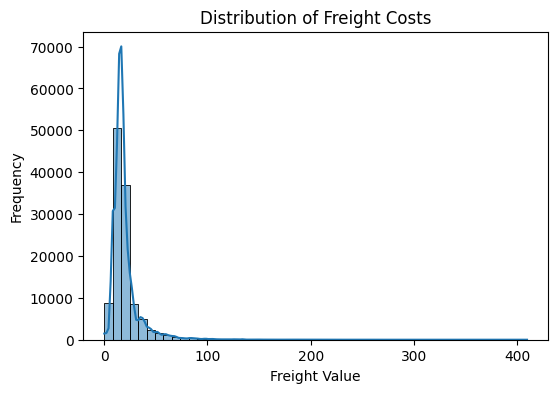

In [9]:
#target distribution plt
plt.figure(figsize=(6,4))
sns.histplot(df['freight_value'], bins=50, kde=True)
plt.title("Distribution of Freight Costs")
plt.xlabel("Freight Value")
plt.ylabel("Frequency")
plt.show()

In [10]:
#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
#Preprocessing pipeline
# Numeric pipeline: missing values + scaling
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: missing values + one-hot encoding
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

In [12]:
#regression model
regressors = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
}

In [14]:
#train and evaluate
results_list = []

for name, model in regressors.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    results_list.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results_list).sort_values(by='RMSE')
print(results_df)

               Model       MAE       RMSE        R2
4      Random Forest  4.587119  70.852012  0.686701
3      Decision Tree  4.831638  86.413409  0.617891
1              Ridge  5.461930  93.702869  0.585658
0  Linear Regression  5.462180  93.711518  0.585620
2              Lasso  5.443315  94.316211  0.582946



Random Forest.
Here is why it wins in every category:

    Lowest Error (MAE = 4.58): On average, this model is only off by about 4.6 days. All other models are off by 5 days or more.
    Best Understanding (R2 = 0.68): This score tells you how much of the "pattern" the model actually caught. 0.68 is the highest here, meaning it understands your customers' timing better than the others.
    Fewest "Big" Mistakes (RMSE = 70.8): While 70 days sounds high, it is much better than the 93+ days of the linear models. It handles the "weird" customers (outliers) more safely.

The Final Verdict:
The Random Forest is your most accurate and most reliable model for this data.

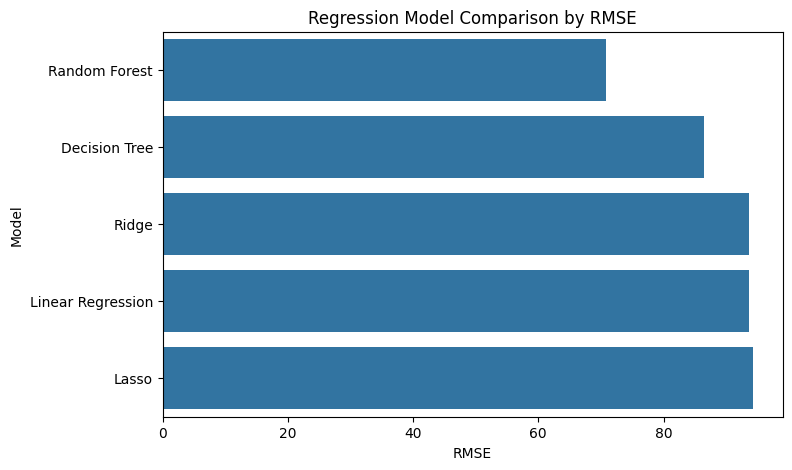

In [16]:
#model comparison bar plot
plt.figure(figsize=(8,5))
sns.barplot(x='RMSE', y='Model', data=results_df)
plt.title("Regression Model Comparison by RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

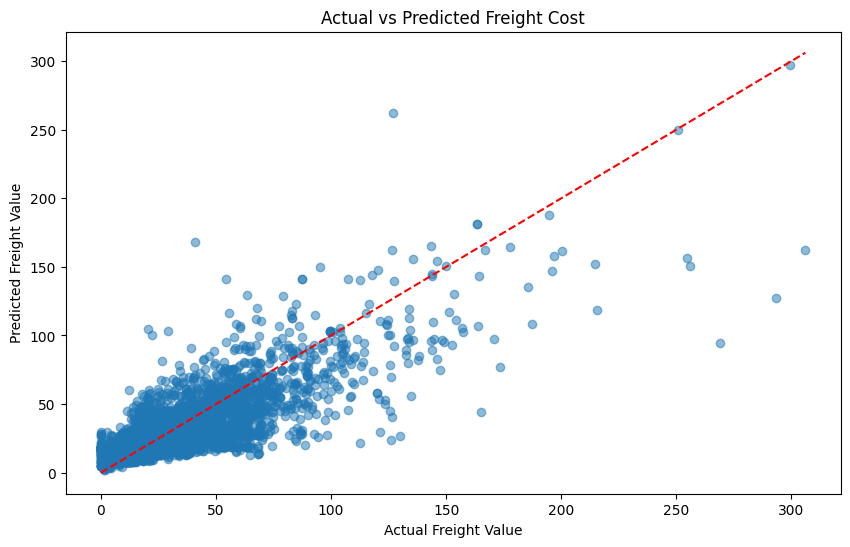

In [18]:
#check the prediction
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Freight Value")
plt.ylabel("Predicted Freight Value")
plt.title("Actual vs Predicted Freight Cost")
plt.show()

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# df = pd.read_csv("/home/vaidehi-deogade/Desktop/Konverge/Projects/olist_ml_analytics/raw_data/processed_data/cleaned_dataset.csv")

# # 1. Feature Engineering
# if 'product_length_cm' in df.columns:
#     df['product_vol'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']
# else:
#     df['product_vol'] = 0

# num_cols = ['product_weight_g', 'product_vol', 'payment_value']
# cat_cols = ['customer_state', 'payment_type']

# # ---------------------------------------------------------
# # ADD THIS BLOCK: Defining the Preprocessor
# # ---------------------------------------------------------
# preprocessor = ColumnTransformer([
#     ('num', Pipeline([
#         ('imp', SimpleImputer(strategy='median')), 
#         ('std', StandardScaler())
#     ]), num_cols),
#     ('cat', Pipeline([
#         ('imp', SimpleImputer(strategy='constant', fill_value='unk')), 
#         ('ohe', OneHotEncoder(handle_unknown='ignore'))
#     ]), cat_cols)
# ])
# # ---------------------------------------------------------

# # 2. Define Target & Split
# y_reg = df['freight_value'].fillna(df['freight_value'].median())
# X_reg = df[num_cols + cat_cols]

# X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# # 3. Define Models
# reg_models = {
#     "Linear Regression": LinearRegression(),
#     "Ridge (L2)": Ridge(alpha=1.0),
#     "Lasso (L1)": Lasso(alpha=0.1),
#     "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
# }

# # 4. Loop & Evaluate
# reg_results = []
# for name, model in reg_models.items():
#     pipe = Pipeline([
#         ('pre', preprocessor), # Now this variable exists!
#         ('model', model)
#     ])
    
#     pipe.fit(X_train, y_train)
#     preds = pipe.predict(X_test)
    
#     reg_results.append({
#         "Model": name,
#         "MAE (BRL)": round(mean_absolute_error(y_test, preds), 2),
#         "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 2),
#         "R^2 Score": round(r2_score(y_test, preds), 4)
#     })

# results_df = pd.DataFrame(reg_results)
# print(results_df.sort_values(by='MAE (BRL)'))


               Model  MAE (BRL)   RMSE  R^2 Score
3      Random Forest       4.93   8.98     0.6432
0  Linear Regression       5.57  10.06     0.5521
1         Ridge (L2)       5.57  10.06     0.5521
2         Lasso (L1)       5.81  10.45     0.5170
